In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Dense, GlobalMaxPool1D, Dropout

[nltk_data] Downloading package stopwords to /Users/oscar/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
df = pd.read_csv("complaints_processed.csv")

df = df.rename(columns={"narrative": "complaint_text"})
df.drop(columns=["Unnamed: 0"], inplace=True, errors="ignore")

print("Shape:", df.shape)
print("Missing text:", df["complaint_text"].isnull().sum())
print(df["product"].value_counts())


Shape: (162421, 2)
Missing text: 10
product
credit_reporting       91179
debt_collection        23150
mortgages_and_loans    18990
credit_card            15566
retail_banking         13536
Name: count, dtype: int64


In [3]:
df = df.dropna(subset=["complaint_text"]).reset_index(drop=True)
df["complaint_text"] = df["complaint_text"].astype(str)

In [4]:
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["product"],
    random_state=42
)

train_df.shape, test_df.shape

((129928, 2), (32483, 2))

In [5]:
stop_words = set(stopwords.words("english"))

def preprocess_text(df):
    df = df.copy()
    
    df["complaint_text"] = df["complaint_text"].str.lower()
    
    # remove non alphabet characters
    df["complaint_text"] = df["complaint_text"].apply(
        lambda x: re.sub(r"[^a-zA-Z\s]", " ", x)
    )
    
    # remove extra spaces
    df["complaint_text"] = df["complaint_text"].apply(
        lambda x: re.sub(r"\s+", " ", x).strip()
    )
    
    # remove stopwords
    df["complaint_text"] = df["complaint_text"].apply(
        lambda x: " ".join(word for word in x.split() if word not in stop_words)
    )
    
    return df

In [6]:
train_df = preprocess_text(train_df)
test_df = preprocess_text(test_df)

In [7]:
le = LabelEncoder()
train_labels = le.fit_transform(train_df["product"])
test_labels = le.transform(test_df["product"])

print(le.classes_)

['credit_card' 'credit_reporting' 'debt_collection' 'mortgages_and_loans'
 'retail_banking']


## Part A - CLASSICAL ML BASELINES

### to check reference performance before applying deep learning

#### TF-IDF Vectorization

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)
)

X_train_tfidf = tfidf.fit_transform(train_df["complaint_text"])
X_test_tfidf = tfidf.transform(test_df["complaint_text"])

#### Logistic Regression (Baseline 1)

In [9]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, class_weight="balanced")

lr.fit(X_train_tfidf, train_labels)
lr_preds = lr.predict(X_test_tfidf)

print("Logistic Regression")
print(classification_report(test_labels, lr_preds))

Logistic Regression
              precision    recall  f1-score   support

           0       0.70      0.83      0.76      3113
           1       0.96      0.84      0.90     18235
           2       0.71      0.84      0.77      4630
           3       0.76      0.88      0.82      3798
           4       0.83      0.90      0.86      2707

    accuracy                           0.85     32483
   macro avg       0.79      0.86      0.82     32483
weighted avg       0.87      0.85      0.85     32483



#### Linear SVM (Baseline 2 – Strong)

In [10]:
from sklearn.svm import LinearSVC

svm = LinearSVC(class_weight="balanced")

svm.fit(X_train_tfidf, train_labels)
svm_preds = svm.predict(X_test_tfidf)

print("Linear SVM")
print(classification_report(test_labels, svm_preds))

Linear SVM
              precision    recall  f1-score   support

           0       0.74      0.82      0.77      3113
           1       0.94      0.89      0.92     18235
           2       0.76      0.80      0.78      4630
           3       0.80      0.86      0.83      3798
           4       0.83      0.89      0.86      2707

    accuracy                           0.87     32483
   macro avg       0.82      0.85      0.83     32483
weighted avg       0.87      0.87      0.87     32483



#### Multinomial Naive Bayes (Baseline 3)

In [11]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()

nb.fit(X_train_tfidf, train_labels)
nb_preds = nb.predict(X_test_tfidf)

print("Naive Bayes")
print(classification_report(test_labels, nb_preds))

Naive Bayes
              precision    recall  f1-score   support

           0       0.69      0.76      0.72      3113
           1       0.91      0.87      0.89     18235
           2       0.76      0.66      0.71      4630
           3       0.72      0.88      0.79      3798
           4       0.81      0.88      0.84      2707

    accuracy                           0.83     32483
   macro avg       0.78      0.81      0.79     32483
weighted avg       0.84      0.83      0.83     32483



## PART B - Bi-LSTM

### Tokenization & Padding

In [9]:
max_words = 5000
max_sequence_length = 170

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(train_df["complaint_text"])

X_train_seq = tokenizer.texts_to_sequences(train_df["complaint_text"])
X_test_seq = tokenizer.texts_to_sequences(test_df["complaint_text"])

X_train_pad = pad_sequences(X_train_seq, maxlen=max_sequence_length)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_sequence_length)

### One-Hot Encode Labels

In [10]:
y_train_cat = to_categorical(train_labels)
y_test_cat = to_categorical(test_labels)

### Bi-LSTM Model

In [15]:
embedding_dim = 64

model = Sequential([
    Embedding(max_words, embedding_dim, input_length=max_sequence_length),
    Bidirectional(LSTM(32, return_sequences=True, dropout=0.3)),
    GlobalMaxPool1D(),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(len(le.classes_), activation="softmax")
])

model.compile(
    loss="categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 170, 64)           320000    
                                                                 
 bidirectional (Bidirection  (None, 170, 64)           24832     
 al)                                                             
                                                                 
 global_max_pooling1d (Glob  (None, 64)                0         
 alMaxPooling1D)                                                 
                                                                 
 dense (Dense)               (None, 64)                4160      
                                                                 
 dropout (Dropout)           (None, 64)                0         
                                                                 
 dense_1 (Dense)             (None, 5)                 3

### Train Bi-LSTM

In [16]:
class_weight = dict(
    zip(
        np.unique(train_labels),
        np.bincount(train_labels).max() / np.bincount(train_labels)
    )
)

history = model.fit(
    X_train_pad,
    y_train_cat,
    validation_data=(X_test_pad, y_test_cat),
    epochs=10,
    batch_size=64,
    class_weight=class_weight
)

Epoch 1/10
2031/2031 [==============================] - 57s 28ms/step - loss: 1.6261 - accuracy: 0.7904 - val_loss: 0.4522 - val_accuracy: 0.8418
Epoch 2/10
2031/2031 [==============================] - 57s 28ms/step - loss: 1.1841 - accuracy: 0.8440 - val_loss: 0.4122 - val_accuracy: 0.8529
Epoch 3/10
2031/2031 [==============================] - 59s 29ms/step - loss: 1.0826 - accuracy: 0.8540 - val_loss: 0.4177 - val_accuracy: 0.8501
Epoch 4/10
2031/2031 [==============================] - 58s 28ms/step - loss: 1.0052 - accuracy: 0.8614 - val_loss: 0.4532 - val_accuracy: 0.8391
Epoch 5/10
2031/2031 [==============================] - 58s 29ms/step - loss: 0.9398 - accuracy: 0.8674 - val_loss: 0.3983 - val_accuracy: 0.8554
Epoch 6/10
2031/2031 [==============================] - 60s 29ms/step - loss: 0.8850 - accuracy: 0.8718 - val_loss: 0.4009 - val_accuracy: 0.8586
Epoch 7/10
2031/2031 [==============================] - 60s 30ms/step - loss: 0.8338 - accuracy: 0.8750 - val_loss: 0.4088 -

### Bi-LSTM Evaluation

In [17]:
lstm_preds = model.predict(X_test_pad)
lstm_preds = np.argmax(lstm_preds, axis=1)

print("Bi-LSTM Results")
print(classification_report(test_labels, lstm_preds))

1016/1016 [==============================] - 5s 5ms/step
Bi-LSTM Results
              precision    recall  f1-score   support

           0       0.68      0.85      0.76      3113
           1       0.97      0.84      0.90     18235
           2       0.71      0.85      0.77      4630
           3       0.76      0.88      0.82      3798
           4       0.85      0.87      0.86      2707

    accuracy                           0.85     32483
   macro avg       0.79      0.86      0.82     32483
weighted avg       0.87      0.85      0.85     32483



### Confusion Matrix

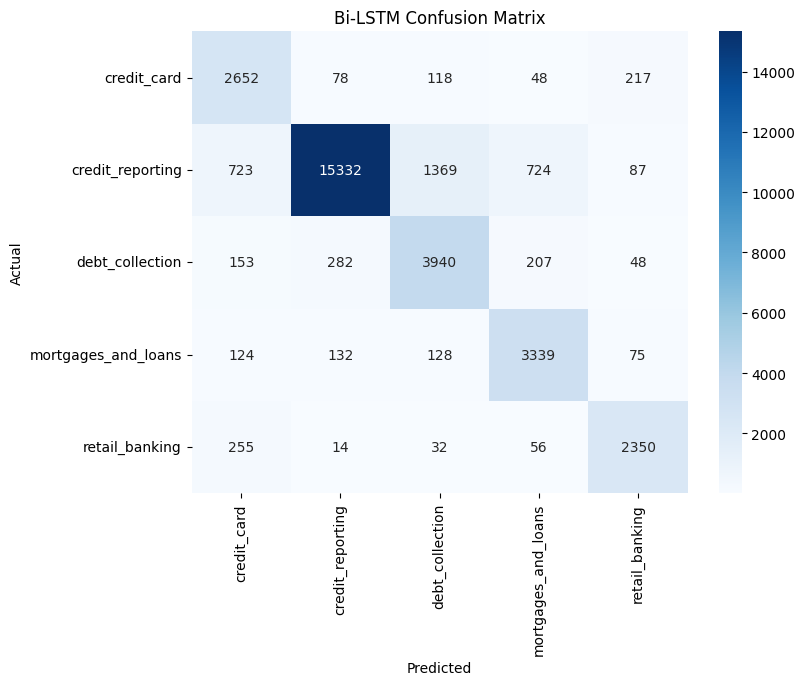

In [18]:
cm = confusion_matrix(test_labels, lstm_preds)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap="Blues"
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Bi-LSTM Confusion Matrix")
plt.show()

In [20]:
from sklearn.metrics import f1_score, accuracy_score

results = []

def add_result(model_name, y_true, y_pred):
    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro_F1": f1_score(y_true, y_pred, average="macro"),
        "Weighted_F1": f1_score(y_true, y_pred, average="weighted")
    })

add_result("Logistic Regression", test_labels, lr_preds)
add_result("Linear SVM", test_labels, svm_preds)
add_result("Naive Bayes", test_labels, nb_preds)
add_result("Bi-LSTM", test_labels, lstm_preds)

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Macro_F1,Weighted_F1
0,Logistic Regression,0.848813,0.820247,0.852627
1,Linear SVM,0.866669,0.832515,0.868411
2,Naive Bayes,0.831266,0.790528,0.831838
3,Bi-LSTM,0.850075,0.820198,0.854516


## TRANSFORMER EXPERIMENT (DistilBERT)

## Tensorflow

### Additional Imports

In [21]:
from transformers import (
    TFDistilBertForSequenceClassification,
    DistilBertTokenizerFast
)

from tensorflow.keras.optimizers import Adam

/Users/oscar/Desktop/MLOps-Practice/Multiclass-Complaints-Classification-Using-Bi-LSTM/venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Prepare Data for Transformer

⚠️ Important difference vs LSTM

No heavy text cleaning

No stopword removal

Keep raw text (lowercasing is enough)

In [22]:
train_texts = train_df["complaint_text"].tolist()
test_texts = test_df["complaint_text"].tolist()

num_labels = len(le.classes_)

### Load Tokenizer

In [23]:
tokenizer_bert = DistilBertTokenizerFast.from_pretrained(
    "distilbert-base-uncased"
)

train_encodings = tokenizer_bert(
    train_texts,
    truncation=True,
    padding=True,
    max_length=256
)

test_encodings = tokenizer_bert(
    test_texts,
    truncation=True,
    padding=True,
    max_length=256
)

### Build TensorFlow Dataset

In [24]:
train_dataset = tf.data.Dataset.from_tensor_slices((
    dict(train_encodings),
    train_labels
)).shuffle(1000).batch(16)

test_dataset = tf.data.Dataset.from_tensor_slices((
    dict(test_encodings),
    test_labels
)).batch(16)

### Load & Compile DistilBERT

In [26]:
# bert_model = TFDistilBertForSequenceClassification.from_pretrained(
#     "distilbert-base-uncased",
#     num_labels=num_labels
# )

# bert_model.compile(
#     optimizer=Adam(learning_rate=2e-5),
#     loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
#     metrics=["accuracy"]
# )

# bert_model.summary()

from transformers import TFDistilBertForSequenceClassification

bert_model = TFDistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=num_labels,
    use_safetensors=False
)
bert_model.compile(
    optimizer=Adam(learning_rate=2e-5),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

bert_model.summary()

Some layers from the model checkpoint at distilbert-base-uncased were not used when initializing TFDistilBertForSequenceClassification: ['vocab_projector', 'vocab_layer_norm', 'activation_13', 'vocab_transform']
- This IS expected if you are initializing TFDistilBertForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some layers of TFDistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['pre_classifier', 'classifier', 'dropout_40']
You should probably TRAIN this model on a down-stream task to be able to use i

Model: "tf_distil_bert_for_sequence_classification_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 distilbert (TFDistilBertMa  multiple                  66362880  
 inLayer)                                                        
                                                                 
 pre_classifier (Dense)      multiple                  590592    
                                                                 
 classifier (Dense)          multiple                  3845      
                                                                 
 dropout_40 (Dropout)        multiple                  0 (unused)
                                                                 
Total params: 66957317 (255.42 MB)
Trainable params: 66957317 (255.42 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


### Train DistilBERT (Short but Powerful)

In [27]:
bert_history = bert_model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=3
)

Epoch 1/3
 208/8121 [..............................] - ETA: 6:12:36 - loss: 1.0104 - accuracy: 0.6442

KeyboardInterrupt: 

### Evaluate DistilBERT

In [ ]:
bert_logits = bert_model.predict(test_dataset).logits
bert_preds = np.argmax(bert_logits, axis=1)

print("DistilBERT Results")
print(classification_report(test_labels, bert_preds))

### RESULTS COMPARISON TABLE (CRITICAL)

In [ ]:
from sklearn.metrics import f1_score, accuracy_score

results = []

def add_result(model_name, y_true, y_pred):
    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro_F1": f1_score(y_true, y_pred, average="macro"),
        "Weighted_F1": f1_score(y_true, y_pred, average="weighted")
    })

add_result("Logistic Regression", test_labels, lr_preds)
add_result("Linear SVM", test_labels, svm_preds)
add_result("Naive Bayes", test_labels, nb_preds)
add_result("Bi-LSTM", test_labels, lstm_preds)
add_result("DistilBERT", test_labels, bert_preds)

results_df = pd.DataFrame(results)
results_df


## PyTorch

#### Imports (PyTorch + HF)

In [12]:
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np

from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification
)

from torch.optim import AdamW
from sklearn.metrics import classification_report


### Exact Same DistilBERT Experiment (PyTorch)

#### Prepare Text & Labels

In [13]:
# optimizer = AdamW(model.parameters(), lr=2e-5)
train_texts = train_df["complaint_text"].tolist()
test_texts = test_df["complaint_text"].tolist()

y_train = train_labels
y_test = test_labels

num_labels = len(le.classes_)


#### Tokenization (Same Logic, Better Stability)

In [14]:
tokenizer = DistilBertTokenizerFast.from_pretrained(
    "distilbert-base-uncased"
)

train_encodings = tokenizer(
    train_texts,
    truncation=True,
    padding=True,
    max_length=256
)

test_encodings = tokenizer(
    test_texts,
    truncation=True,
    padding=True,
    max_length=256
)


#### Custom Dataset Class (IMPORTANT)

In [15]:
class ComplaintDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)


#### Create DataLoaders

In [16]:
train_dataset = ComplaintDataset(train_encodings, y_train)
test_dataset = ComplaintDataset(test_encodings, y_test)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16)

#### Load DistilBERT (PyTorch Native)

In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=num_labels
)

model.to(device)


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSdpaAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


#### Optimizer & Training Setup

In [18]:
optimizer = AdamW(model.parameters(), lr=2e-5)
epochs = 3


#### Training Loop (Simple & Clean)

In [19]:
model.train()

for epoch in range(epochs):
    total_loss = 0
    
    for batch in train_loader:
        optimizer.zero_grad()
        
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)
        
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )
        
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(train_loader):.4f}")


KeyboardInterrupt: 

In [20]:
# Reduce dataset size (VERY IMPORTANT)
train_df_small = train_df.sample(n=10000, random_state=42)
test_df_small  = test_df.sample(n=2000, random_state=42)
# Reduce max sequence length
train_encodings = tokenizer(
    train_texts,
    truncation=True,
    padding=True,
    max_length=128
)
# Reduce batch size
train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True
)
# Reduce epochs
epochs = 2

In [21]:
model.train()

for epoch in range(epochs):
    total_loss = 0
    
    for batch in train_loader:
        optimizer.zero_grad()
        
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)
        
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )
        
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(train_loader):.4f}")


KeyboardInterrupt: 

In [ ]:
for step, batch in enumerate(train_loader):
    if step % 100 == 0:
        print(f"Step {step}/{len(train_loader)}")

#### Evaluation (Same as Other Models)

In [ ]:
model.eval()
preds = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        
        logits = outputs.logits
        preds.extend(torch.argmax(logits, dim=1).cpu().numpy())

print("DistilBERT (PyTorch) Results")
print(classification_report(y_test, preds))


In [ ]:
from sklearn.metrics import f1_score, accuracy_score

results = []

def add_result(model_name, y_true, y_pred):
    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro_F1": f1_score(y_true, y_pred, average="macro"),
        "Weighted_F1": f1_score(y_true, y_pred, average="weighted")
    })

add_result("Logistic Regression", test_labels, lr_preds)
add_result("Linear SVM", test_labels, svm_preds)
add_result("Naive Bayes", test_labels, nb_preds)
add_result("Bi-LSTM", test_labels, lstm_preds)
# add_result("DistilBERT (TensorFlow)", test_labels, bert_preds)
add_result("DistilBERT (PyTorch)", y_test, preds)

results_df = pd.DataFrame(results)
results_df